In [ ]:
import pickle
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import pandas as pd
import glob
import os
import re

# === Load optimization_inputs from .pkl ===
with open("optimization_inputs.pkl", "rb") as f:
    optimization_inputs = pickle.load(f)

# === Step 1: Load claim counts from Excel files ===
data_dir = "services"
xlsx_files = sorted(
    glob.glob(os.path.join(data_dir, "services_*.xlsx")),
    key=lambda f: int(re.search(r"services_(\d+)_", os.path.basename(f)).group(1))
)
claim_counts = []

for file in xlsx_files:
    df = pd.read_excel(file)
    claim_counts.append(len(df))

total_claims = sum(claim_counts)
weights = [c / total_claims for c in claim_counts]  # service usage weights

# === Adaptive epsilon_i ===
K = 0.4
epsilons = [min(0.05, K / np.sqrt(n)) for n in claim_counts]

# === Show epsilon & weight info ===
print("\n===== Service-Level Weights and Δ Bounds =====")
for i, (n_claims, eps, w) in enumerate(zip(claim_counts, epsilons, weights), start=1):
    print(f"Service {i}: {n_claims} claims → ε = {eps:.4f}, weight = {w:.4f}")

# === Gurobi Setup ===
lambda_penalty = 0.01
M = 1e7
n = len(optimization_inputs)

model = gp.Model("MIQP_Weighted")
delta = model.addVars(n, lb=-GRB.INFINITY, name="delta")
m_vars = {}
z_vars = {}

for i, service in enumerate(optimization_inputs):
    m_vars[i] = []
    z_vars[i] = []
    for j in range(len(service["c_ij"])):
        m = model.addVar(lb=0.0, name=f"m_{i}_{j}")
        z = model.addVar(vtype=GRB.BINARY, name=f"z_{i}_{j}")
        m_vars[i].append(m)
        z_vars[i].append(z)

model.update()

# === Constraints ===
model.addConstr(gp.quicksum(delta[i] for i in range(n)) == 0, name="budget_neutral")

for i, service in enumerate(optimization_inputs):
    limit_i = service["limit"]
    c_ij = service["c_ij"]
    p_ij = service["p_ij"]
    T_i = limit_i + delta[i]
    eps_i = epsilons[i]

    model.addConstr(delta[i] <= eps_i * limit_i, name=f"delta_max_{i}")
    model.addConstr(delta[i] >= -eps_i * limit_i, name=f"delta_min_{i}")

    for j in range(len(c_ij)):
        c = c_ij[j]
        m = m_vars[i][j]
        z = z_vars[i][j]
        model.addConstr(m <= T_i)
        model.addConstr(m <= c)
        model.addConstr(m >= T_i - M * (1 - z))
        model.addConstr(m >= c - M * z)

# === Weighted Objective ===
quad_obj = gp.QuadExpr()

for i, service in enumerate(optimization_inputs):
    p_ij = service["p_ij"]
    m_i = m_vars[i]
    w_i = weights[i]

    expected_i = gp.LinExpr()
    for j in range(len(p_ij)):
        expected_i += p_ij[j] * m_i[j]

    expected_sq = gp.QuadExpr()
    for j in range(len(p_ij)):
        expected_sq += p_ij[j] * m_i[j] * m_i[j]

    squared_expected = gp.QuadExpr()
    for j in range(len(p_ij)):
        for k in range(len(p_ij)):
            squared_expected += p_ij[j] * p_ij[k] * m_i[j] * m_i[k]

    variance_i = expected_sq - squared_expected
    quad_obj += w_i * (expected_i + lambda_penalty * variance_i)

model.setObjective(quad_obj, GRB.MINIMIZE)

# === Solve ===
model.setParam('Presolve', 0)
model.setParam('Heuristics', 0)
model.setParam('Cuts', 0)
model.setParam('MIPFocus', 1)
model.optimize()

# === Print Results ===
print("\n===== FINAL OPTIMIZATION RESULTS =====")
for i in range(n):
    old = optimization_inputs[i]["limit"]
    d = delta[i].X
    new = old + d
    print(f"Service {i+1}: original = {int(old):,}, Δ = {int(d):+,.0f}, adjusted = {int(new):,}")


===== Service-Level Weights and Δ Bounds =====
Service 1: 2 claims → ε = 0.0500, weight = 0.0013
Service 2: 7 claims → ε = 0.0500, weight = 0.0044
Service 3: 18 claims → ε = 0.0500, weight = 0.0114
Service 4: 19 claims → ε = 0.0500, weight = 0.0120
Service 5: 41 claims → ε = 0.0500, weight = 0.0260
Service 6: 75 claims → ε = 0.0462, weight = 0.0476
Service 7: 128 claims → ε = 0.0354, weight = 0.0812
Service 8: 962 claims → ε = 0.0129, weight = 0.6100
Service 9: 36 claims → ε = 0.0500, weight = 0.0228
Service 10: 143 claims → ε = 0.0334, weight = 0.0907
Service 11: 146 claims → ε = 0.0331, weight = 0.0926
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter MIPFocus to value 1
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[rosetta2] - Darwin 25.3.0 25D2128)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
Heuristics  0
MIPFocus  1
Cuts  0
Presol

In [10]:
print(f"Objective value: {model.ObjVal:,.2f}")
 

Objective value: 39,223,106.71


In [11]:
import pandas as pd

# Extract results
delta_result = [delta[i].X for i in range(n)]
adjusted_limits = [optimization_inputs[i]["limit"] + delta_result[i] for i in range(n)]

# Create DataFrame
results = pd.DataFrame({
    "ServiceIndex": list(range(1, n + 1)),
    "OriginalLimit": [s["limit"] for s in optimization_inputs],
    "Delta": delta_result,
    "AdjustedLimit": adjusted_limits
})

results["DeltaPercent"] = (results["Delta"] / results["OriginalLimit"]) * 100

# Export to CSV
results.to_csv("optimized_limits.csv", index=False)
print("✅ Exported to optimized_limits.csv")



✅ Exported to optimized_limits.csv


✅ Exported to optimized_limits2.xlsx


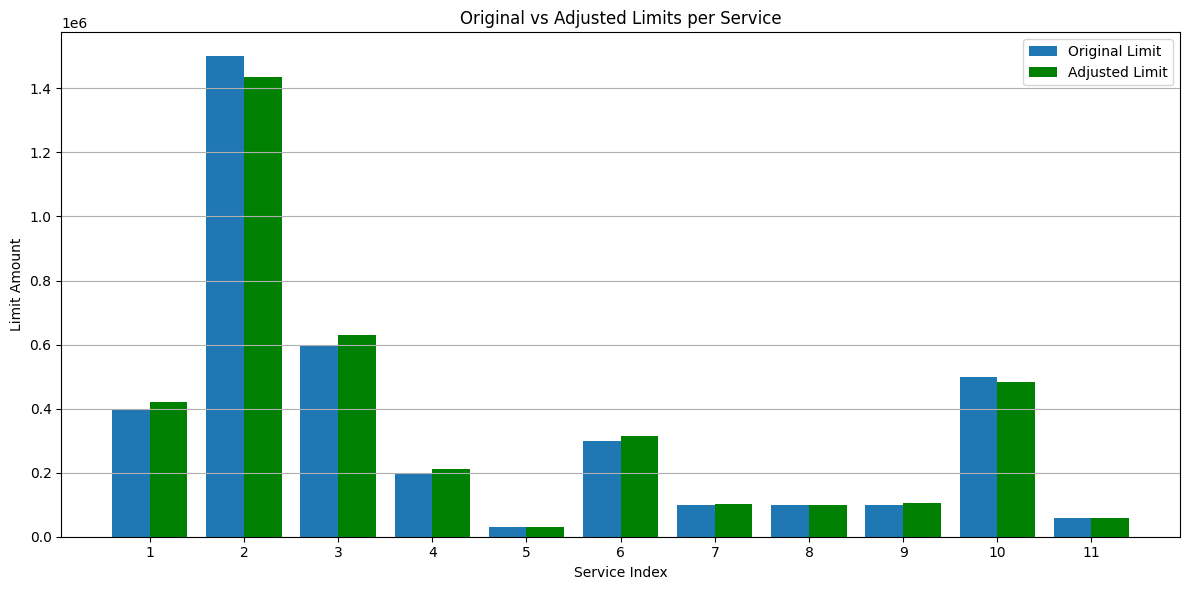


📄 Paste these rows into your LaTeX table:

1 & 400,000 & +20,000 & 420,000 & +5.00\% \\
2 & 1,500,000 & -63,891 & 1,436,108 & -4.26\% \\
3 & 600,000 & +30,000 & 630,000 & +5.00\% \\
4 & 200,000 & +10,000 & 210,000 & +5.00\% \\
5 & 30,000 & +1,500 & 31,500 & +5.00\% \\
6 & 300,000 & +13,856 & 313,856 & +4.62\% \\
7 & 100,000 & +3,535 & 103,535 & +3.54\% \\
8 & 100,000 & -1,289 & 98,710 & -1.29\% \\
9 & 100,000 & +5,000 & 105,000 & +5.00\% \\
10 & 500,000 & -16,724 & 483,275 & -3.34\% \\
11 & 60,000 & -1,986 & 58,013 & -3.31\% \\


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# === Step 1: Extract results ===
delta_result = [delta[i].X for i in range(n)]
adjusted_limits = [optimization_inputs[i]["limit"] + delta_result[i] for i in range(n)]

results = pd.DataFrame({
    "ServiceIndex": list(range(1, n + 1)),
    "OriginalLimit": [s["limit"] for s in optimization_inputs],
    "Delta": delta_result,
    "AdjustedLimit": adjusted_limits
})

results["DeltaPercent"] = (results["Delta"] / results["OriginalLimit"]) * 100

# === Step 2: Export to Excel ===
results.to_excel("optimized_limits2.xlsx", index=False)
print("✅ Exported to optimized_limits2.xlsx")

# === Step 3: Plot ===
plt.figure(figsize=(12, 6))
plt.bar(results["ServiceIndex"] - 0.2, results["OriginalLimit"], width=0.4, label="Original Limit")
plt.bar(results["ServiceIndex"] + 0.2, results["AdjustedLimit"], width=0.4, label="Adjusted Limit", color='green')

plt.xlabel("Service Index")
plt.ylabel("Limit Amount")
plt.title("Original vs Adjusted Limits per Service")
plt.xticks(results["ServiceIndex"])
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.savefig("limits_comparison_plot.png", dpi=300)
plt.show()

# === Step 4: Generate LaTeX Table Rows ===
print("\n📄 Paste these rows into your LaTeX table:\n")
for idx, row in results.iterrows():
    print(f"{int(row['ServiceIndex'])} & {int(row['OriginalLimit']):,} & {int(row['Delta']):+,.0f} & {int(row['AdjustedLimit']):,} & {row['DeltaPercent']:+.2f}\\% \\\\")
